In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os
import cv2
import csv
import json
import numpy as np
import tensorflow as tf
from tensorflow import keras
from datetime import datetime
from base64 import b64decode
from google.colab import output
from IPython.display import display, Javascript
import matplotlib.pyplot as plt

np.random.seed(1000)
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'


In [13]:
MODEL_PATH = "/content/drive/MyDrive/CVPR/alexnet_attendance.h5"
model = keras.models.load_model(MODEL_PATH)
print("Model loaded")


Model loaded


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/CVPR/Faces"

class_names = sorted(os.listdir(DATASET_PATH))
print("Classes:", class_names)


Classes: ['Akshay Kumar', 'Alexandra Daddario', 'Alia Bhatt', 'Amitabh Bachchan', 'Andy Samberg', 'Anushka Sharma', 'Billie Eilish', 'Brad Pitt', 'Camila Cabello', 'Charlize Theron', 'Claire Holt', 'Courtney Cox', 'Dwayne Johnson', 'Elizabeth Olsen', 'Ellen Degeneres', 'Henry Cavill', 'Hrithik Roshan', 'Hugh Jackman', 'Jessica Alba', 'Lisa Kudrow', 'Margot Robbie', 'Natalie Portman', 'Priyanka Chopra', 'Robert Downey Jr', 'Tom Cruise', 'Vijay Deverakonda', 'Virat Kohli', 'Zac Efron']


In [ ]:
def take_photo(filename='photo.jpg', quality=0.8):
    js = Javascript('''
    async function takePhoto(quality) {
      const div = document.createElement('div');
      const video = document.createElement('video');
      div.appendChild(video);
      document.body.appendChild(div);

      const stream = await navigator.mediaDevices.getUserMedia({video: true});
      video.srcObject = stream;
      await video.play();

      const canvas = document.createElement('canvas');
      canvas.width = video.videoWidth;
      canvas.height = video.videoHeight;
      canvas.getContext('2d').drawImage(video, 0, 0);

      stream.getTracks().forEach(track => track.stop());
      div.remove();

      return canvas.toDataURL('image/jpeg', quality);
    }
    ''')
    display(js)
    data = output.eval_js('takePhoto({})'.format(quality))
    binary = b64decode(data.split(',')[1])
    with open(filename, 'wb') as f:
        f.write(binary)
    return cv2.imread(filename)


In [ ]:
IMG_SIZE = 227

def preprocess(img):
    img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
    img = img.astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)
    return img


In [ ]:
ATTENDANCE_FILE = "/content/drive/MyDrive/CVPR/attendance.csv"

def mark_attendance(name):
    with open(ATTENDANCE_FILE, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([name, datetime.now().strftime("%Y-%m-%d %H:%M:%S")])


<IPython.core.display.Javascript object>

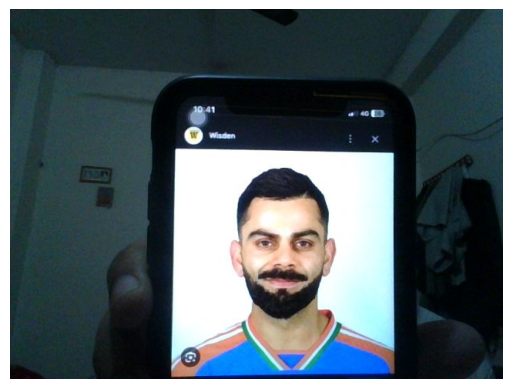

Prediction: Virat Kohli
Confidence: 0.8762308955192566
Attendance marked for Virat Kohli


In [35]:
img = take_photo()

plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

input_img = preprocess(img)

pred = model.predict(input_img, verbose=0)
class_id = np.argmax(pred)
confidence = float(np.max(pred))
name = class_names[class_id]

print("Prediction:", name)
print("Confidence:", confidence)

if confidence > 0.50:
    mark_attendance(name)
    print(f"Attendance marked for {name}")
else:
    print("Confidence too low — attendance NOT marked")
